# Groundwater Response to Rainfall
by Leah Montgomery

## Introduction
Groundwater recharge is an import part of the hydrological cycle. Aquifers are primarily supplied by recharge from precipitation on the Earths surface moving downwards to the saturated zone. It is crucial to understand how this process occurs, including the rate at which infiltration occurs and how long it takes for water to reach the saturated zone. This information is important for future planning, gruondwater use, and understanding the reliability of a water source. In a study by Teramoto et al. cross correlation is used to determine the significant lag time for a single sandstone aquifer in Brazil. To determine the lag time, they cross-correlated the head values against precipitation, which is a common approach to estimating lag times. They then used a groundwater model to determine recharge values and cross-correlated these values with precipitation as well. Through this method they would determine that their model values were more reliable based on having stronger correlations. There are many different ways of quantifying recharge, the simplist method uses the change in groundwater head. I decided to use similar methods to this study, but instead of using recharge values, I used the increase in groundwater head. These methods are often used for individual aquifers when trying to understand recharge behaviors. However, they do not often compare various site to see if they behave different or similarly. I was interested to see how these results would change depending on the geology of the location, so I decided to find sites that had aquifers in different geological units.    

In the Teramoto et al. study, they performed a cross correlation between precipitation and change in groundwater head. The highest correlation they found was .1, relating to 169 day lag. Similar to the study, I used one full year of data and looked at correlations for up to 365 days of lag. I decided to look at the correlation between precipitation with a few different groundwater values. I used the actual groundwater head values from my data set, then I calculated the change in head for each day, and finally I smoothed the original data to remove any excess noise and used those values as well. Overall, I wanted to see how much impact these changes had on the correlation as well, in order to see how well each values actually estimated the lag times. 

I acquired groundwater monitoring data from USGS monitoring wells. I attempted to choose wells located in various geological units, so that I can analyze the difference in lag times depending on the geology. Then, I acquired my precipitations data from NOAA NCEI daily observation sites. I chose the closest sites to my observation wells, and was able to obtain data near all of my wells. 

The question that I want to answer in this study is how does aquifer geology affect the lag time between precipitation and change in head. I predict that the confined aquifer will have a much longer lag time and lower correlation, while the sand and gravel aquifer will have a shorter lag time and a higher correlation. Based on the Teramoto et al. paper, I expected the lag values could be very large and the correlations may be smaller than expected. I also want to see if I get a higher correlation for the change in head values when compared to the raw head values for each location. 

##  Locations 

|  | Lafayette Indiana | Warner New Hampshire | Byers Colorado | Baton Rouge Louisiana |
|--|--|--|--|--|
| Aquifer type | Sand and Gravel | Stratified drift | Confined Sandstone | Unconfined Sand |


## Lafayette Indiana groundwater and precipitation monitoring stations  
The Lafayette Indiana Aquifer is an unconfined sand and gravel aquifer that lies under a river. It supplies water to the surrounding town and university. Because of this, it is important to understand all aspects of this water resource. The groundwater well lies at an altitude of 386 ft above sea level. I chose this site because I knew that this aquifer has high recharge rates, and would potentially have a fast lag time. 

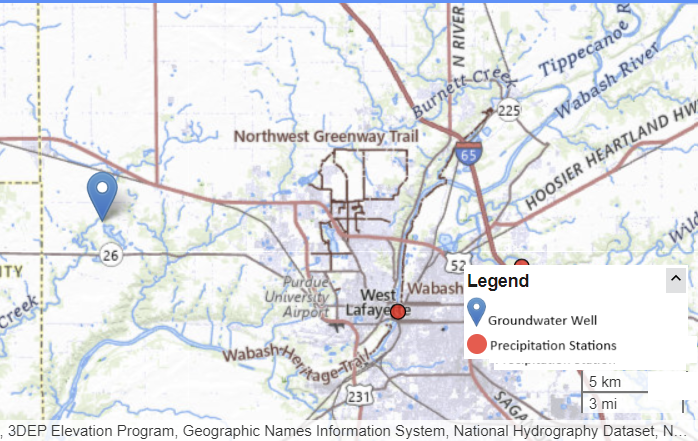

## Warner New Hampshire groundwater and precipitation monitoring stations  
The Warner New Hampshire Aquifer is an unconfined aquifer made of stratified glacial till. The groundwater well for this location lies at an altiude of 421 feet above sea level. I chose this aquifer because I knew that the aquifers in this area have slower recharge rates and are not as easily affected by precipitation. I wanted to see how the correlation would behave with such an aquifer.

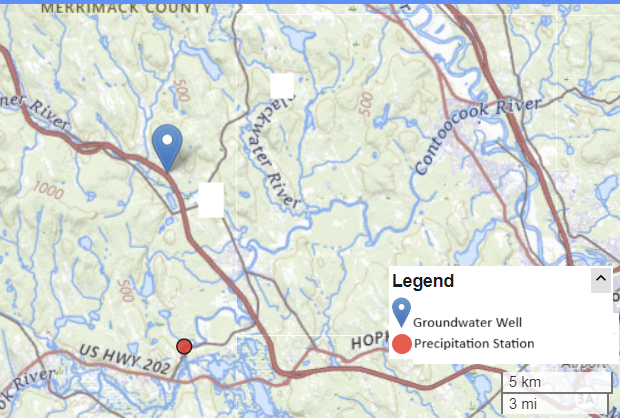

## Byers Colorado groundwater and precipitation monitoring stations  
The Byers Colorado Aquifer is a confined sandstone aquifer with impermeable clay layers. The groundwater well for this location lies at an altitude of 5120 feet above sea level. I chose this aquifer because it is a confined aquifer. I wanted to see what results I would get with a confined aquifer instead of unconfined. 

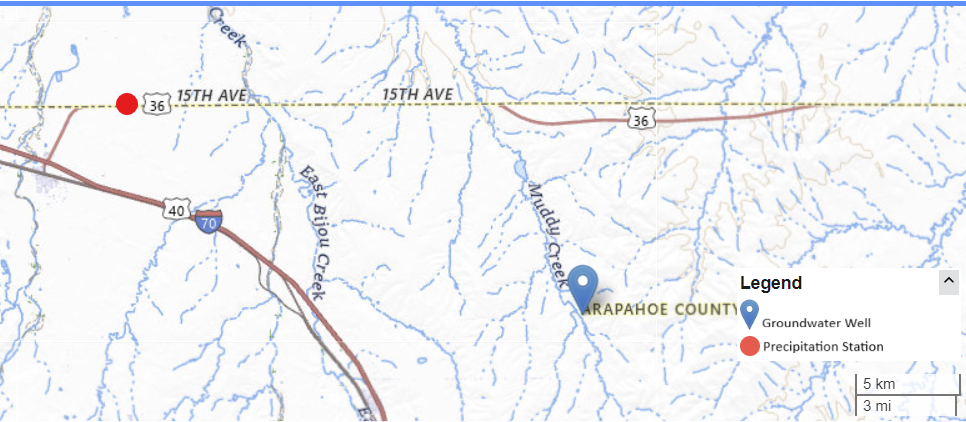

## Baton Rouge Louisiana groundwater and precipitation monitoring stations 
The Baton Rouge Louisiana aquifer is a single layer sand aquifer. This is a part of a large regional aquifer system that supplies water to multiple states. The groundwater well for this location lies at 44 feet above sea level. I chose this aquifer because it is an important source of water for multiple states surrounding Louisiana. 

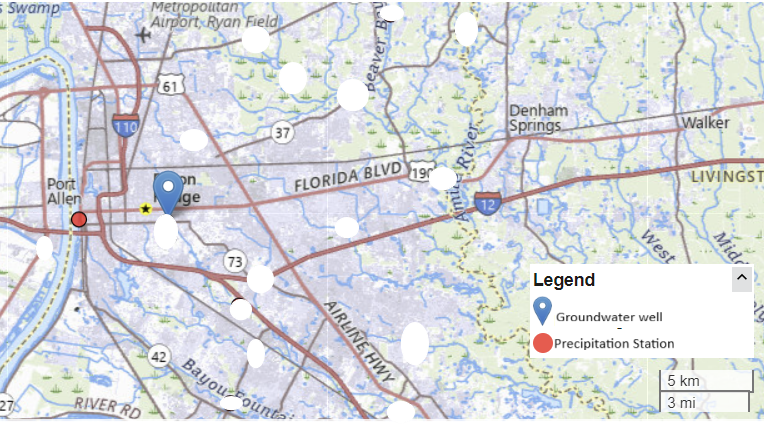

## Methods

The first step in my analysis is to collect precipitation data and depth to water data for various locations. I stored this data in folders, then specified the paths of these folders in order to access the individual files. I also specified the start and end of the study period. I created a function to read in the csv files, and a seperate function to read in the txt files. These functions read in the appropriate data, and clean the data so that it can be used in my analysis. The groundwater data function also resamples the data to daily measurements in order to match the date index of the precipitation data. Additionally, both of these functions fill any missing data. After reading in the data, I used the altitude values that were obtained from the USGS site pages to convert the depth to water values into feet above sea level. This way, when I do the cross correlation analysis, a positive correlation coefficient will mean that an increase in precipitation leads to an increase in head. Finally, I smoothed the data to get rid of noise.  

After cleaning the data, I plot all locations to show precipitation against groundwater changes. From this, we can visually see if there is a clear relationship between precipitation and groundwater head. We can see for the Colorado well that there is very little change in groundwater over the entire year. 

Finally, I used a function to compute the cross correlation. This function calls a seperate function that I created that actually calculates the correaltions. It then plots all of the coefficients against the lag values for all 4 locations. Finally, I stored all of the maximum lag values in dataframes and printed them to see what the best correlations were. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
import os
from pathlib import Path
from scipy.signal import savgol_filter
import functions as fn

In [2]:
cwd = os.getcwd()
groundwater_data = Path(cwd)/"dtw_Data"
Precip_data = Path(cwd)/"Precip_data"
start_date = "2024-10-01"
end_date = "2025-09-30"
in_altitude = 386.42
nh_altitude = 421.15
co_altitude = 5120
la_altitude = 44

In [3]:
nh_p = fn.read_csv_p('NH_Precip.csv', cwd, Precip_data, start_date, end_date)
co_p = fn.read_csv_p('CO_Precip.csv', cwd, Precip_data, start_date, end_date)
in_p = fn.read_csv_p('IN_Precip.csv', cwd, Precip_data, start_date, end_date)
la_p = fn.read_csv_p('LA_Precip.csv', cwd, Precip_data, start_date, end_date)

In [4]:
nh_gw = fn.read_txt_dtw('Indiana_dtw.txt', cwd, groundwater_data, start_date, end_date)
co_gw = fn.read_txt_dtw('MuddyCreekCO_dtw.txt', cwd, groundwater_data, start_date, end_date)
in_gw = fn.read_txt_dtw('WarnerNH_dtw.txt', cwd, groundwater_data, start_date, end_date)
la_gw = fn.read_txt_dtw('Louisiana_dtw.txt', cwd, groundwater_data, start_date, end_date)

## Raw Data 

This is an example of the precipitation data and groundwater data after being read in, and before the groundwater head and change in head is calculated. 

In [5]:
nh_p

,Precip
DATE,
2024-10-01,0.00
2024-10-02,0.00
2024-10-03,0.00
2024-10-04,0.00
2024-10-05,0.03
...,...
2025-09-26,1.64
2025-09-27,0.00
2025-09-28,0.00


In [6]:
nh_gw

,dtw,diff
Date,,
2024-10-01,22.505625,0.006667
2024-10-02,22.512292,0.006667
2024-10-03,22.519792,0.007500
2024-10-04,22.545729,0.025937
2024-10-05,22.544479,-0.001250
...,...,...
2025-09-26,22.840729,0.005729
2025-09-27,22.853125,0.012396
2025-09-28,22.879583,0.026458


Next I calculate the head values using the altitude of each location, and then I calculate the change in head for each day and drop all negative values to get only the increase in head. 

In [7]:
nh_gw = fn.read_txt_dtw('Indiana_dtw.txt', cwd, groundwater_data, start_date, end_date)
co_gw = fn.read_txt_dtw('MuddyCreekCO_dtw.txt', cwd, groundwater_data, start_date, end_date)
in_gw = fn.read_txt_dtw('WarnerNH_dtw.txt', cwd, groundwater_data, start_date, end_date)
la_gw = fn.read_txt_dtw('Louisiana_dtw.txt', cwd, groundwater_data, start_date, end_date)

#%%Convert from dtw to head elevation 
nh_gw['head'] = nh_altitude - nh_gw['dtw']
in_gw['head'] = in_altitude - in_gw['dtw']
co_gw['head'] = co_altitude - co_gw['dtw']
la_gw['head'] = la_altitude - la_gw['dtw']

#add in a diff column for head
nh_gw['diff'] = nh_gw['head'].diff()
in_gw['diff'] = in_gw['head'].diff()
co_gw['diff'] = co_gw['head'].diff()
la_gw['diff'] = la_gw['head'].diff()

Finally I used the savgol_filter function to get rid of any noise in the head values. This is to help remove the high variability in the correlation values. I found that filtering over 50 days keeps the overall trends while minimizing noise. 

In [8]:
y = nh_gw['head']
y_filt = savgol_filter(y, 50, 2)
nh_gw['head_filt'] = y_filt

y2 = co_gw['head']
y_filt2 = savgol_filter(y2, 50, 2)
co_gw['head_filt'] = y_filt2

y3 = in_gw['head']
y_filt3 = savgol_filter(y3, 50, 2)
in_gw['head_filt'] = y_filt3

y4 = la_gw['head']
y_filt4 = savgol_filter(y4, 50, 2)
la_gw['head_filt'] = y_filt4

This is the groundwater data after going through these changes. 

In [9]:
nh_gw

,dtw,diff,head,head_filt
Date,,,,
2024-10-01,22.505625,NaN,398.644375,398.646720
2024-10-02,22.512292,-0.006667,398.637708,398.636269
2024-10-03,22.519792,-0.007500,398.630208,398.626027
2024-10-04,22.545729,-0.025937,398.604271,398.615995
2024-10-05,22.544479,0.001250,398.605521,398.606172
...,...,...,...,...
2025-09-26,22.840729,-0.005729,398.309271,398.292459
2025-09-27,22.853125,-0.012396,398.296875,398.285283
2025-09-28,22.879583,-0.026458,398.270417,398.278189


# Plots

Now I want to show the precipitation and groundwater head values for all 4 locations. This gives us a good idea of how the groundwater is behaving. For example, Byers Colorado has almost no change in head. This makes sense for a confined aquifer. 

Text(0.5, 0, 'Time')

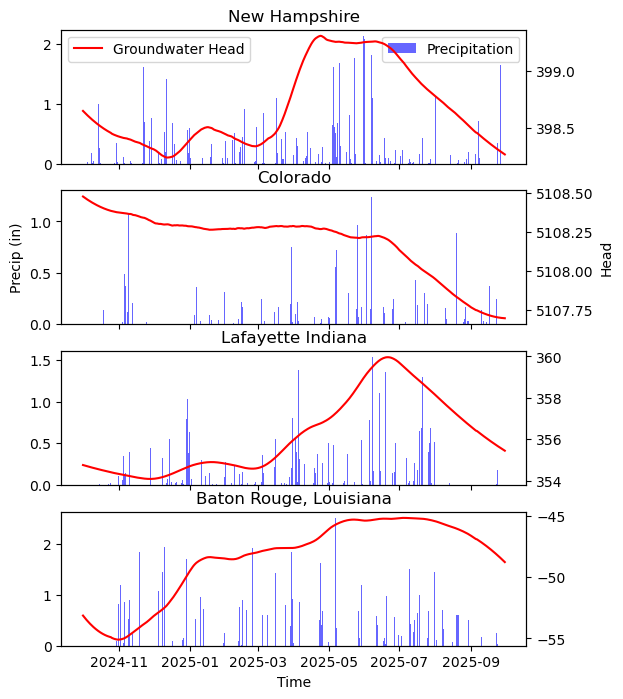

In [10]:
fig, (ax1, ax2, ax3, ax7) = plt.subplots(nrows=4, ncols=1, sharex=True)
fig.set_size_inches(6,8)

ax1.bar(nh_p.index, nh_p['Precip'], color='blue', alpha=0.6, label='Precipitation')
ax4 = ax1.twinx()
#ax4.plot(nh_gw.index, nh_gw['head'], color='darkgreen')
ax4.plot(nh_gw.index, nh_gw['head_filt'], color='red', label='Groundwater Head')
ax1.set_title("New Hampshire")
ax1.legend()
ax4.legend()

ax2.bar(co_p.index, co_p['Precip'], color='blue', alpha=0.6)
ax5 = ax2.twinx()
ax5.plot(co_gw.index, co_gw['head_filt'], color='red')
ax5.set_ylabel('Head')
ax2.set_ylabel('Precip (in)')
ax2.set_title("Colorado")

ax3.bar(in_p.index, in_p['Precip'], color='blue', alpha=0.6)
ax6 = ax3.twinx()
#ax6.plot(in_gw.index, in_gw['dtw'], color='darkgreen')
ax6.plot(in_gw.index, in_gw['head_filt'], color='red')
ax3.set_title("Lafayette Indiana")

ax7.bar(la_p.index, la_p['Precip'], color='blue', alpha=0.6)
ax8 = ax7.twinx()
#ax6.plot(in_gw.index, in_gw['dtw'], color='darkgreen')
ax8.plot(la_gw.index, la_gw['head_filt'], color='red')
ax7.set_title("Baton Rouge, Louisiana")
ax7.set_xlabel('Time')


Next I compute the cross-correlations for each location and visually graph them to see the variability and any high correlation values. First I graphes the filtered head values, then the change in groundwater head, and finally the raw head values. 

This is the filtered correlation coefficients


C:\Users\User\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\User\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


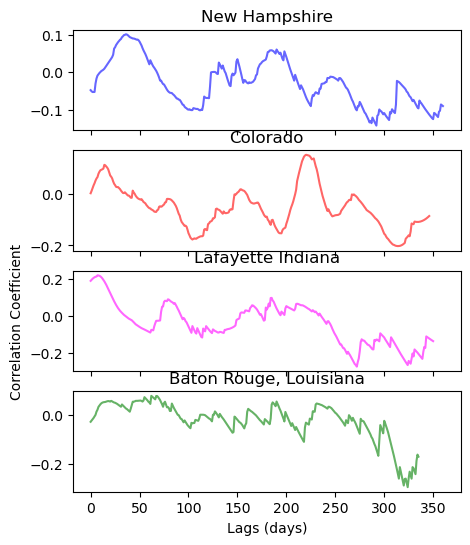

In [11]:
print('This is the filtered correlation coefficients')
filt_corrs = fn.plot_corr(in_p, nh_p, co_p, la_p, in_gw, nh_gw, co_gw, la_gw, 'Precip', 'head_filt')

This is the change in groundwater correlation coefficients


C:\Users\User\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\User\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


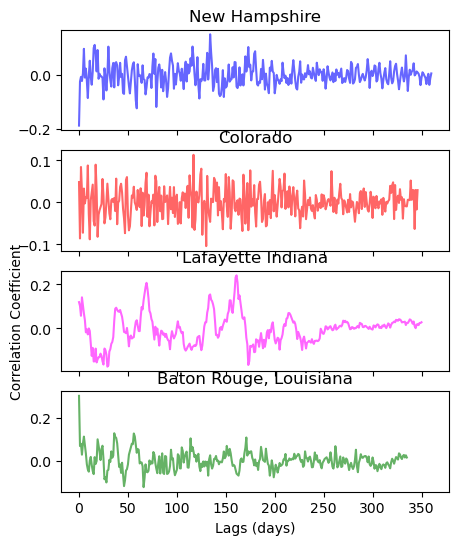

In [12]:
print('This is the change in groundwater correlation coefficients')
diff_corrs = fn.plot_corr(in_p, nh_p, co_p, la_p, in_gw, nh_gw, co_gw, la_gw, 'Precip', 'diff')

This is the heads correlation coefficients


C:\Users\User\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\User\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


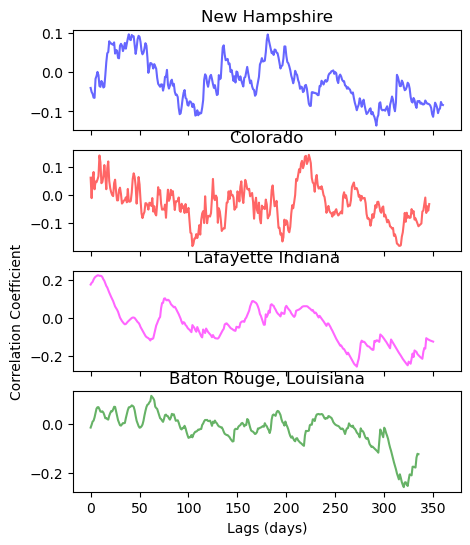

In [13]:
print('This is the heads correlation coefficients')
head_corrs = fn.plot_corr(in_p, nh_p, co_p, la_p, in_gw, nh_gw, co_gw, la_gw, 'Precip', 'head')

In [14]:
nh_max = head_corrs['NH'].max()
in_max = head_corrs['IN'].max()
co_max = head_corrs['CO'].max()
la_max = head_corrs['LA'].max()
nh_index = head_corrs['NH'].idxmax()
in_index = head_corrs['IN'].idxmax()
co_index = head_corrs['CO'].idxmax()
la_index = head_corrs['LA'].idxmax()

column_names = ['Correlation', 'Lag (days)']
index_labels = ['New Hampshire', 'Indiana', 'Colorado', 'Louisiana']
data = np.array([
    [nh_max, nh_index], 
    [in_max, in_index], 
    [co_max, co_index],
    [la_max, la_index]
    ])
head_table = pd.DataFrame(data=data, index=index_labels, columns=column_names)


In [15]:
nh_max_diff = diff_corrs['NH'].max()
in_max_diff = diff_corrs['IN'].max()
co_max_diff = diff_corrs['CO'].max()
la_max_diff = diff_corrs['LA'].max()
nh_index_diff = diff_corrs['NH'].idxmax()
in_index_diff = diff_corrs['IN'].idxmax()
co_index_diff = diff_corrs['CO'].idxmax()
la_index_diff = diff_corrs['LA'].idxmax()

column_names = ['Correlation', 'Lag (days)']
index_labels = ['New Hampshire', 'Indiana', 'Colorado', 'Louisiana']
data = np.array([
    [nh_max_diff, nh_index_diff], 
    [in_max_diff, in_index_diff], 
    [co_max_diff, co_index_diff],
    [la_max_diff, la_index_diff]
    ])
diff_table = pd.DataFrame(data=data, index=index_labels, columns=column_names)

In [16]:
nh_max_f = filt_corrs['NH'].max()
in_max_f = filt_corrs['IN'].max()
co_max_f = filt_corrs['CO'].max()
la_max_f = filt_corrs['LA'].max()
nh_index_f = filt_corrs['NH'].idxmax()
in_index_f = filt_corrs['IN'].idxmax()
co_index_f = filt_corrs['CO'].idxmax()
la_index_f = filt_corrs['LA'].idxmax()

column_names = ['Correlation', 'Lag (days)']
index_labels = ['New Hampshire', 'Indiana', 'Colorado', 'Louisiana']
data = np.array([
    [nh_max_f, nh_index_f], 
    [in_max_f, in_index_f], 
    [co_max_f, co_index_f],
    [la_max_f, la_index_f]
    ])
filt_table = pd.DataFrame(data=data, index=index_labels, columns=column_names)

# Max values 

Finally, I compiled the correlations for all four locations and stored them in dataframes. I then determined the maximum lags for each locations and stored those in seperate tables. Here is the correlations for the raw head values. 

In [17]:
head_corrs.head(10)

,IN,NH,CO,LA,lags
0,0.175011,-0.040255,0.060620,-0.013843,0
1,0.183992,-0.050472,-0.011967,-0.002574,1
2,0.188947,-0.055199,0.058691,0.010634,2
3,0.201438,-0.064826,0.080720,0.014485,3
4,0.210565,-0.065544,0.019544,0.027612,4
5,0.216492,-0.016948,0.046984,0.046523,5
6,0.219682,-0.010029,0.044549,0.063607,6
7,0.223607,0.000643,0.053926,0.069348,7
8,0.223510,-0.007529,0.065797,0.069653,8
9,0.221070,-0.035474,0.139440,0.061521,9


These are the tables storing the maximum lag times for each location. I start with the raw head values, then I show the filtered head values, and finally the change in groundwater head. 

In [18]:
print('This is the table of correlation for the head values')
head_table

This is the table of correlation for the head values


,Correlation,Lag (days)
New Hampshire,0.096400,39.0
Indiana,0.223607,7.0
Colorado,0.141732,223.0
Louisiana,0.115850,62.0


In [19]:
print('This is the table of correlation for the filtered head values')
filt_table

This is the table of correlation for the filtered head values


,Correlation,Lag (days)
New Hampshire,0.101179,36.0
Indiana,0.217658,7.0
Colorado,0.149569,220.0
Louisiana,0.078319,62.0


In [20]:
print('This is the table of correlation for the difference values')
diff_table

This is the table of correlation for the difference values


,Correlation,Lag (days)
New Hampshire,0.150526,134.0
Indiana,0.241360,161.0
Colorado,0.113313,117.0
Louisiana,0.306573,0.0


# Frequency

My last analysis is showing the frequency of the head values versus the frequency in the change in head. I chose to look at the frequency in order to see if the high correlation lags were unique. If there was a high frequency of correlations near the highest value, that tells me that the highest correlation lag may not be a unique value. If there is a low frequency, that tells me that the highest correlation lag is unique, and may be a better representation of lag time. 
You can see that there is a larger spread of correlations in the raw head values when compared to the change in head values. 

These plots are the frequency of the correlation coefficients for the head values


Text(0.5, 0, 'Correlation Coefficient')

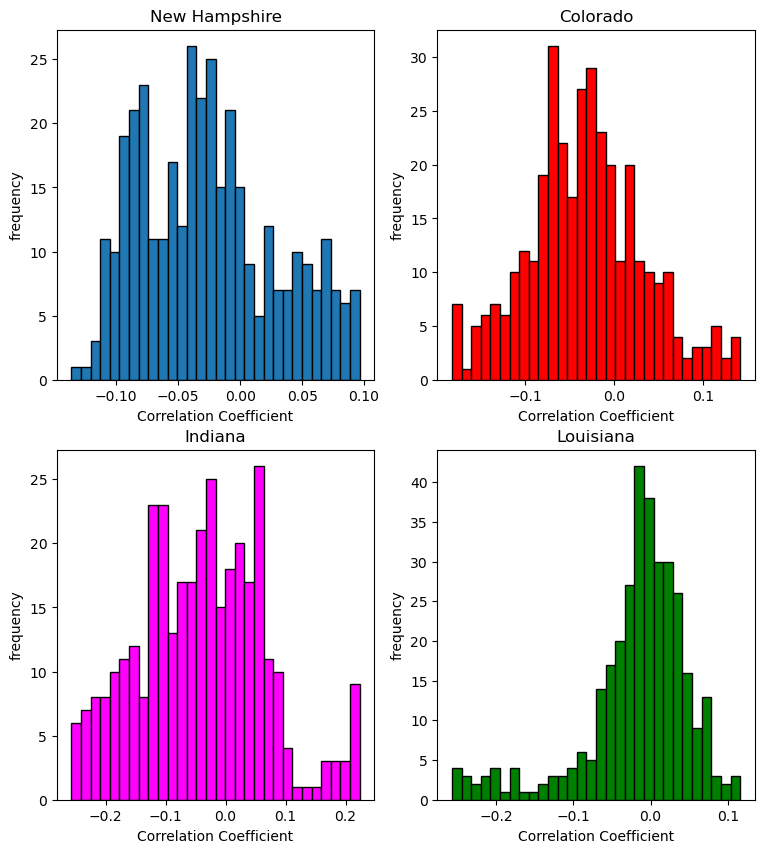

In [25]:
print('These plots are the frequency of the correlation coefficients for the head values')
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, sharex=False)
fig.set_size_inches(9,10)

ax1.hist(head_corrs['NH'], bins=30, edgecolor='black')
ax1.set_title('New Hampshire')
ax1.set_ylabel('frequency')
ax1.set_xlabel('Correlation Coefficient')
ax2.hist(head_corrs['CO'], bins=30, color = 'red', edgecolor='black')
ax2.set_title('Colorado')
ax2.set_ylabel('frequency')
ax2.set_xlabel('Correlation Coefficient')
ax3.hist(head_corrs['IN'], bins=30, color = 'magenta', edgecolor='black')
ax3.set_title('Indiana')
ax3.set_ylabel('frequency')
ax3.set_xlabel('Correlation Coefficient')
ax4.hist(head_corrs['LA'], bins=30, color = 'green', edgecolor='black')
ax4.set_title('Louisiana')
ax4.set_ylabel('frequency')
ax4.set_xlabel('Correlation Coefficient')

These plots are the frequency of the correlation coefficients for the change in head values


Text(0.5, 0, 'Correlation Coefficient')

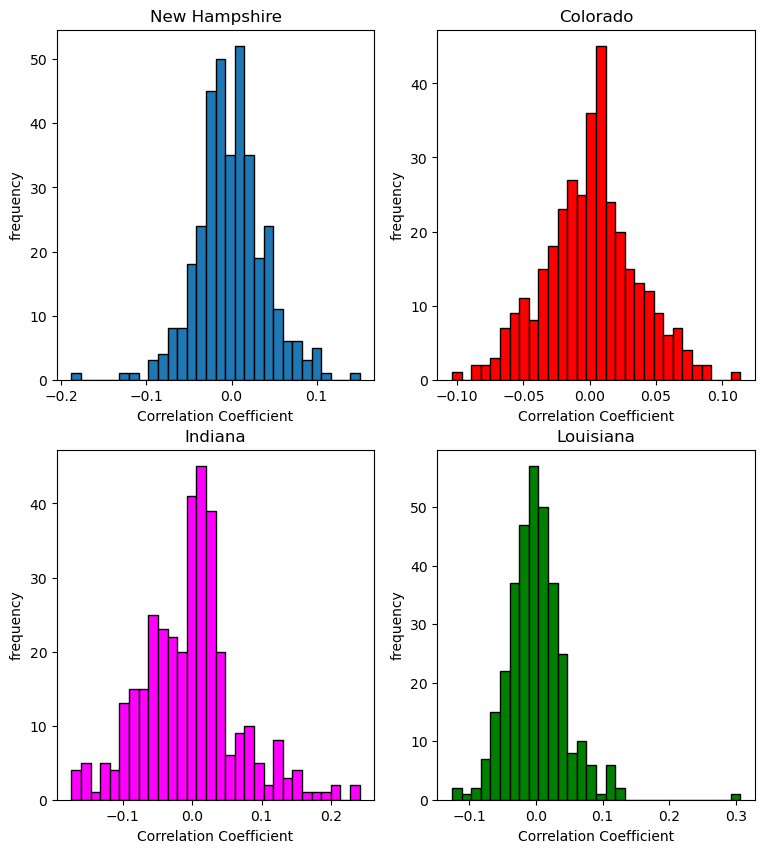

In [26]:
print('These plots are the frequency of the correlation coefficients for the change in head values')
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, sharex=False)
fig.set_size_inches(9,10)

ax1.hist(diff_corrs['NH'], bins=30, edgecolor='black')
ax1.set_title('New Hampshire')
ax1.set_ylabel('frequency')
ax1.set_xlabel('Correlation Coefficient')
ax2.hist(diff_corrs['CO'], bins=30, color = 'red', edgecolor='black')
ax2.set_title('Colorado')
ax2.set_ylabel('frequency')
ax2.set_xlabel('Correlation Coefficient')
ax3.hist(diff_corrs['IN'], bins=30, color = 'magenta', edgecolor='black')
ax3.set_title('Indiana')
ax3.set_ylabel('frequency')
ax3.set_xlabel('Correlation Coefficient')
ax4.hist(diff_corrs['LA'], bins=30, color = 'green', edgecolor='black')
ax4.set_title('Louisiana')
ax4.set_ylabel('frequency')
ax4.set_xlabel('Correlation Coefficient')

## Results 
The results for this study are very interesting. For the head values and the filtered head values, Indiana had the shortest lag time of one week. The next shortest was New Hampshire, with a little over 1 month. Next was Louisiana, a little over 2 months. And finally colorado had the largest lag time, over 220 days. For both of these analysis, correlation values typically were between .7 and .23. While these values do not indicate a very strong correlation, they are consistent with the values that were obtained in Teramoto et al. 

Although these are the max correlation for each site, there are many other lag times that come close to these values as well. These means that there may be multiple lag times that could be used for each aquifer. 

## Discussion 
While there are much more reliable ways of estimating recharge, cross correlation has been used to attempt to estimate the amount of time it takes for precipitation to enter the saturated zone. Cas we can see from my results, confined aquifers such as in Byers Colorado have long lag times, with water taking a much longer time to recharge when compared to unconfined units. 

The first results that I was to discuss are the raw head values for the aquifer. My raw data was in depth to water values, which are typically in feet below the surface. This format makes correlation difficult and often confusing, so I decided to convert these values to feet above sea level. I did this by using the altitude given by the USGS and subtracted the depth the water values from the altitude. This was the data that I refered to as 'heads' in the groundwater dataframes. I used these values to perform a cross correlation against precipitation. A postitive correlation means that as precipitation increase, so does the groundwater head. Therefore, high correlation coefficients means that there is a strong relationship at that specific lag time. For this analysis, I found that Lafayette Indiana had the highest correlation of about 0.22 and a lag time of about 7 days. This means that there is a correlation between precipitation events and an increase in head 7 days later. This was also the shortest lag time of all 4 locations. The longest lag time was for Byers Colorado. The max correlation was 0.14 with a lag time of 223 days. This result makes sense because this aquifer is a confined sandstone aquifer, so we would expect really long lag times. In fact, we can see from the initial graphs of the raw data that the head values for colorado hardly change at all throughout the year. Warner New Hampshire had the weakest correaltion of about 0.09, associated with a lag of 39 days. Finally, Baton Rouge Louisiana had a correlation of 0.11 for a lag time of 62 days. 

The next result that I want to discuss if the filtered head values. Based on the raw data, there was a lot of noise in the data. I decided to filter the head values to try to remove any noise that may mess with my results. I used a Savitzky–Golay filter to smooth the data, with a window size of about 50. I chose this value based on trial and error. I wanted to make sure I got rid of the noise, while also keeping the general trends on the data. I then repeated the above process for my filtered head values. I got very similar results to my unfiltered head values. The lag times were slightly lower, and the correlation was slightly less for Louisiana and slightly more for New Hampshire. Overall, I do not believe that filtering the data had a large impact on my results. 

Finally, I wanted to correlate the change in groundwater head against precipitation. In a very simplistic manner, we can think of a positive change in head as the recharge to the aquifer. This is certaintly not the best way to estimate reacharge, but for the sake of this study a simplistic method would be best. To calculate the change, I used the .diff() function, which calculates the difference between each value and the one before it. I then set all negative values to zero, in order to approximate the "recharge" values for each day. I did this because theoretically, any increase in hydraulic head can be attributed to recharge, but negative values would be discharge from the aquifer. After doing this, I proceeded to do the same cross correlation analysis that I did to the other two sets of data. For this set, I found that my max correlation values were larger than using the head values. Interestingly, I did find that the max correlation for Louisiana occured at 0 days. I am not completely sure why this happened, but we can see from the plot that there were a few other lags that had higher correlations around 40 and 55 days.  

In order to see how often there were high correlations, I made histograms showing the frequency of different correlation coefficients. For the head values, we can see that most of the correlations are close to zero, however there are also many correlations that come close to or go over 0.2. For the change in head we see a very different behavior. A majority of the correlations are close to zero, with only a handful of correlations getting up to or over 0.2. For the change in head, it was less common to see high correlation values than there was for the raw head values. This gives me more confidence that these lag times are unique. 

These results show us that there is a difference in the lag times of different aquifers, which makes sense based on what we know about aquifer properties. It is common to assume that these lag times are the time it takes for precipitation to reach the saturated zones, however it is important to note that this method is highly uncertain. By taking the change in groundwater head, it gives us another recharge estimation that may be more accurate than using the head values. Because this data gave higher correlations for the maximum lags, it is more certain than the other methods. However, there is still unceratintly in this data especially with the confined aquifer data. 

## Conclusion
Through this analysis, I have found that the correlation between change in groundwater head and precipitation varies greatly between different aquifers depending on a range of factors. In this study I investigated the geology of the aquifers, but this is only one factor that I believe has a strong impact. In future studies, it would be interesting to compare correlations for aquifers of different shallowness, different climates, and perhaps different elevations. To study those I would choose to isolate those variable to see how large of an impact they have. Additionally, it would be good to take land use into account for this analysis to ensure that all locations had the same land use. In this study, I believe some of the vairability of the correlations is due to some of these factors, but they could also be due to overlapping rainfall events. These events may throw off the correlations because of multiple large rain events happening within the a short amount of time. By knowing what factors impact these results, we can work to refine correlations and better understand their overall meaning. Overall, this method worked well for the analysis that I wanted to do, and gave me results that were similar to those seen in literature. 

## Literature cited 

Teramoto, E.H., Crioni, P.L.B. & Chang, H.K. Daily time series of groundwater recharge derived from temporal variation of water level. Sustain. Water Resour. Manag. 7, 67 (2021). https://doi.org/10.1007/s40899-021-00546-4